# OPRA Policy Evaluation

Evaluates DRL-AR-VDDPS simulated logs against the BPCI_2012 DDPS reference log.

In [10]:
import pandas as pd
from log_distance_measures.config import EventLogIDs
from log_distance_measures.control_flow_log_distance import control_flow_log_distance
from log_distance_measures.absolute_event_distribution import absolute_event_distribution_distance
from log_distance_measures.case_arrival_distribution import case_arrival_distribution_distance
from log_distance_measures.config import AbsoluteTimestampType, discretize_to_hour
from log_distance_measures.cycle_time_distribution import cycle_time_distribution_distance
import matplotlib.pyplot as plt

In [11]:
log_name = "AcademicCredentials"
log1 = pd.read_csv(f"data/logs/{log_name}/{log_name}_train.csv")
log2 = pd.read_csv(f"data/simulated_logs/{log_name}V2/{log_name}_DDPS_10.csv")
log3 = pd.read_csv(f"data/simulated_logs/{log_name}V3/{log_name}_DDPS_10.csv")
#log3 = pd.read_csv(f"data/evaluation_results/{log_name}/DRL-AR/simulated_logs/sim_run_10.csv")
# data/simulated_logs/{log_name}/{log_name}_DDPS_v2.csv
tag = "V3"
original_ids = EventLogIDs(
    case="case_id",
    activity="activity",
    start_time="start_time",
    end_time="end_time",
    resource="resource",
)    

simulated_ids = EventLogIDs(
    case="case_id",
    activity="activity",
    start_time="start_time",
    end_time="end_time",
    resource="resource",
)

log1[original_ids.start_time] = pd.to_datetime(log1[original_ids.start_time], utc=True, format="mixed")
log1[original_ids.end_time]   = pd.to_datetime(log1[original_ids.end_time], utc=True, format="mixed")

log2[simulated_ids.start_time] = pd.to_datetime(log2[simulated_ids.start_time], utc=True, format="mixed")
log2[simulated_ids.end_time]   = pd.to_datetime(log2[simulated_ids.end_time], utc=True, format="mixed")

log3[simulated_ids.start_time] = pd.to_datetime(log3[simulated_ids.start_time], utc=True, format="mixed")
log3[simulated_ids.end_time]   = pd.to_datetime(log3[simulated_ids.end_time], utc=True, format="mixed")

cfld_value = control_flow_log_distance(
    log1, original_ids,
    log2, simulated_ids
)

cfld_value_rl = control_flow_log_distance(
    log1, original_ids,
    log3, simulated_ids
)

print("CFLD (Normal):", cfld_value)
print(f"CFLD ({tag}):", cfld_value_rl)

abs_dist = absolute_event_distribution_distance(
    log1, original_ids,
    log2, simulated_ids,
    discretize_type=AbsoluteTimestampType.BOTH,
    discretize_event=discretize_to_hour
)

abs_dist_rl = absolute_event_distribution_distance(
    log1, original_ids,
    log3, simulated_ids,
    discretize_type=AbsoluteTimestampType.BOTH,
    discretize_event=discretize_to_hour
)


print("Absolute Event Distribution Distance:", abs_dist)
print(f"Absolute Event Distribution Distance ({tag}):", abs_dist_rl)

cad_dist = case_arrival_distribution_distance(
    log1, original_ids,
    log2, simulated_ids,
    discretize_event=discretize_to_hour
)

cad_dist_rl = case_arrival_distribution_distance(
    log1, original_ids,
    log3, simulated_ids,
    discretize_event=discretize_to_hour
)

print("Case Arrival Distribution Distance:", cad_dist)
print(f"Case Arrival Distribution Distance ({tag}):", cad_dist_rl)


cad_dist = cycle_time_distribution_distance(
    log1, original_ids,
    log2, simulated_ids,
    bin_size=pd.Timedelta(hours=1)
)

cad_dist_rl = cycle_time_distribution_distance(
    log1, original_ids,
    log3, simulated_ids,
    bin_size=pd.Timedelta(hours=1)
)

print("Cycle Time Distribution Distance:", cad_dist)
print(f"Cycle Time Distribution Distance ({tag}):", cad_dist_rl)


CFLD (Normal): 0.13965702778516847
CFLD (V3): 0.13965702778516847
Absolute Event Distribution Distance: 50.43421006537498
Absolute Event Distribution Distance (V3): 50.43421006537498
Case Arrival Distribution Distance: 52.547738693467345
Case Arrival Distribution Distance (V3): 52.547738693467345
Cycle Time Distribution Distance: 33.53517587939699
Cycle Time Distribution Distance (V3): 33.53517587939699


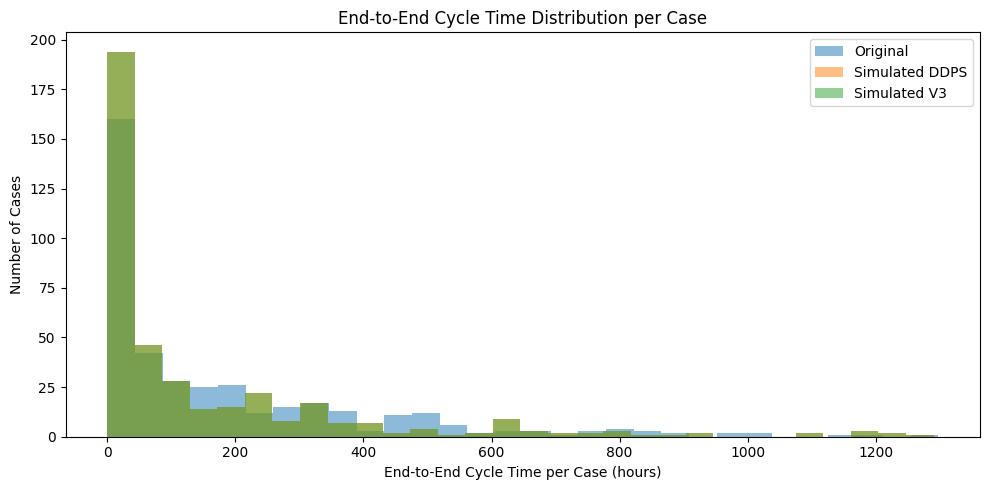

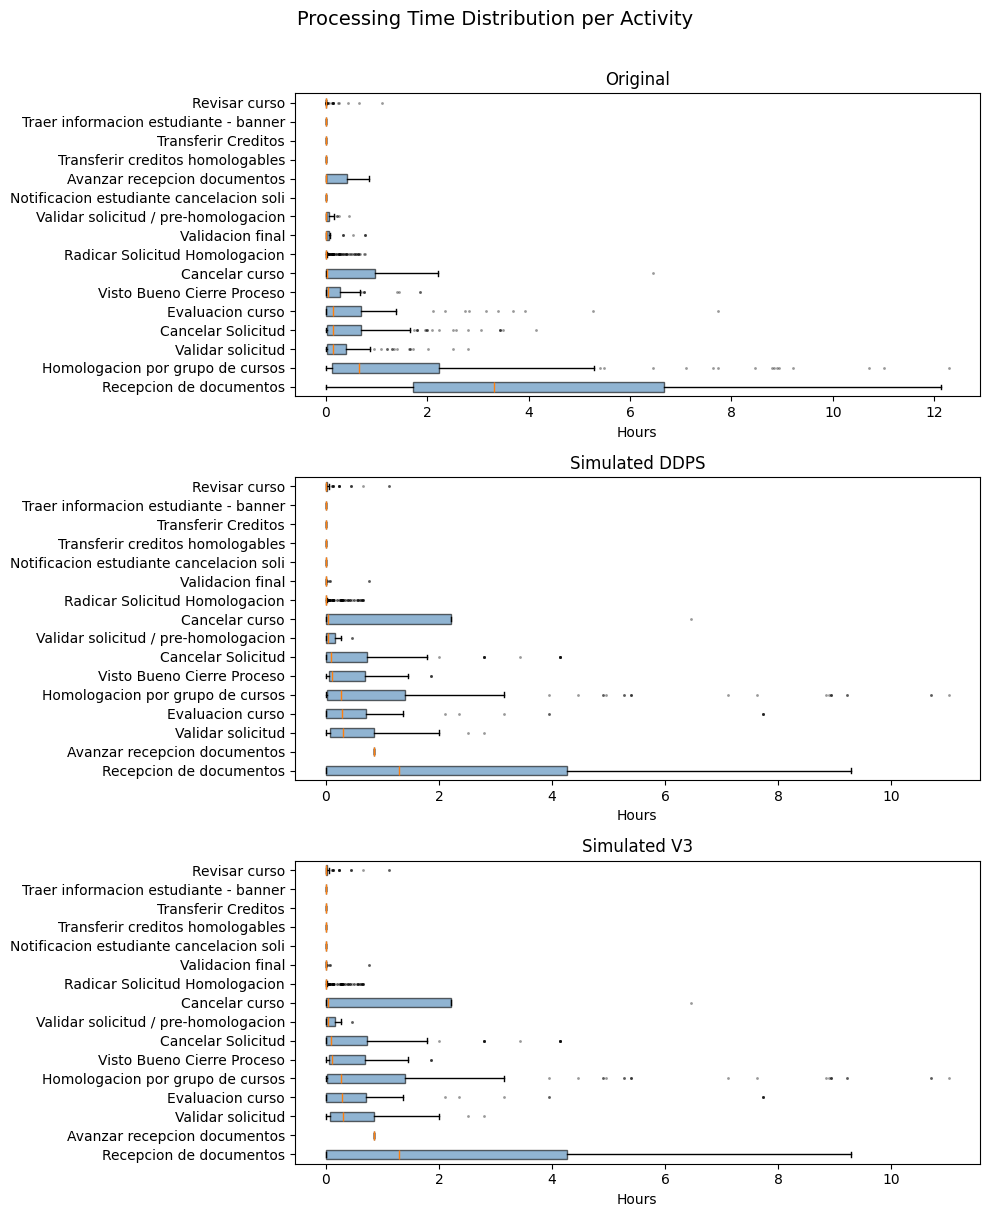

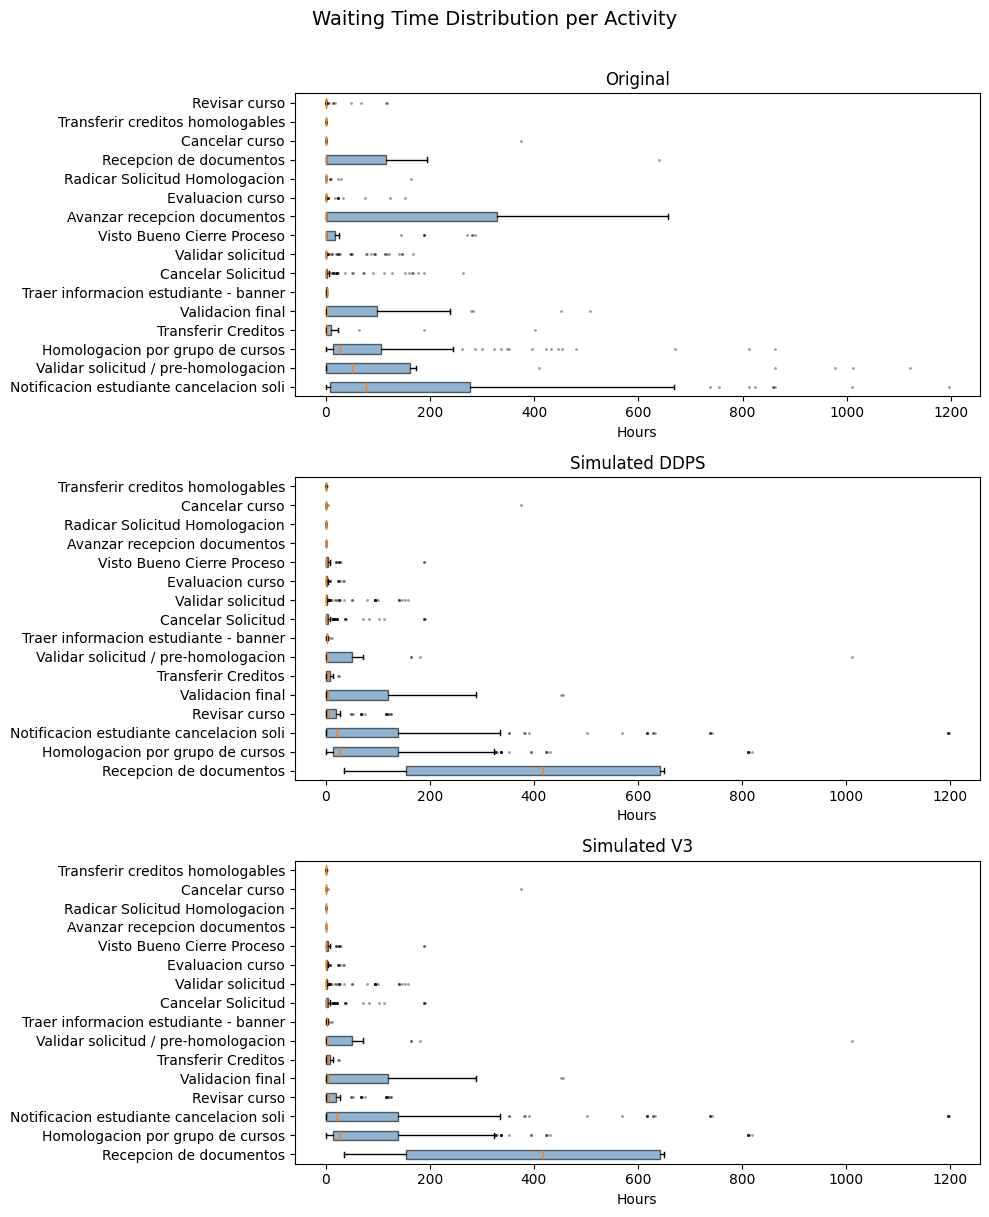

In [12]:
# Compare end-to-end Cycle Time Distributions (per case)
def case_cycle_times(log, ids):
    grouped = log.groupby(ids.case)
    return (grouped[ids.end_time].max() - grouped[ids.start_time].min()).dt.total_seconds() / 3600

ct1 = case_cycle_times(log1, original_ids)
ct2 = case_cycle_times(log2, simulated_ids)
ct3 = case_cycle_times(log3, simulated_ids)

plt.figure(figsize=(10, 5))
plt.hist(ct1, bins=30, alpha=0.5, label="Original")
plt.hist(ct2, bins=30, alpha=0.5, label="Simulated DDPS")
plt.hist(ct3, bins=30, alpha=0.5, label=f"Simulated {tag}")
plt.xlabel("End-to-End Cycle Time per Case (hours)")
plt.ylabel("Number of Cases")
plt.legend()
plt.title("End-to-End Cycle Time Distribution per Case")
plt.tight_layout()
plt.show()

# Processing time & waiting time distributions per activity
def add_times(log, ids):
    log = log.sort_values([ids.case, ids.start_time]).copy()
    log["processing_time"] = (log[ids.end_time] - log[ids.start_time]).dt.total_seconds() / 3600
    log["prev_end"] = log.groupby(ids.case)[ids.end_time].shift(1)
    log["waiting_time"] = ((log[ids.start_time] - log["prev_end"]).dt.total_seconds() / 3600).clip(lower=0)
    return log

log1 = add_times(log1, original_ids)
log2 = add_times(log2, simulated_ids)
log3 = add_times(log3, simulated_ids)

def boxplot_per_activity(logs_labels, value_col, title):
    n = len(logs_labels)
    fig, axes = plt.subplots(n, 1, figsize=(10, n * 4))
    if n == 1:
        axes = [axes]
    for ax, (log, ids, label) in zip(axes, logs_labels):
        activities = log.groupby(ids.activity)[value_col].median().sort_values(ascending=False).index.tolist()
        grouped = [log.loc[log[ids.activity] == a, value_col].dropna().values for a in activities]
        ax.boxplot(grouped, vert=False, tick_labels=activities,
                    flierprops=dict(marker=".", markersize=2, alpha=0.4),
                    patch_artist=True, boxprops=dict(facecolor="steelblue", alpha=0.6))
        ax.set_xlabel("Hours")
        ax.set_title(label)
    fig.suptitle(title, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

logs_labels = [
    (log1, original_ids, "Original"),
    (log2, simulated_ids, "Simulated DDPS"),
    (log3, simulated_ids, f"Simulated {tag}"),
]
boxplot_per_activity(logs_labels, "processing_time", "Processing Time Distribution per Activity")
boxplot_per_activity(logs_labels, "waiting_time", "Waiting Time Distribution per Activity")


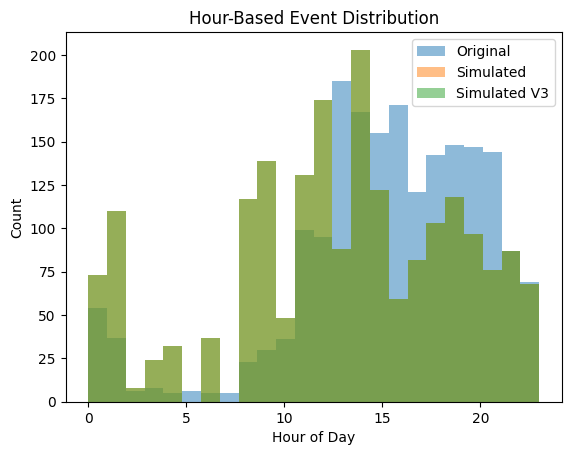

In [13]:
log1["hour"] = log1[original_ids.start_time].dt.hour
log2["hour"] = log2[simulated_ids.start_time].dt.hour
log3["hour"] = log3[simulated_ids.start_time].dt.hour

plt.hist(log1["hour"], bins=24, alpha=0.5, label="Original")
plt.hist(log2["hour"], bins=24, alpha=0.5, label="Simulated")
plt.hist(log3["hour"], bins=24, alpha=0.5, label=f"Simulated {tag}")

plt.xlabel("Hour of Day")
plt.ylabel("Count")
plt.legend()
plt.title("Hour-Based Event Distribution")
plt.show()

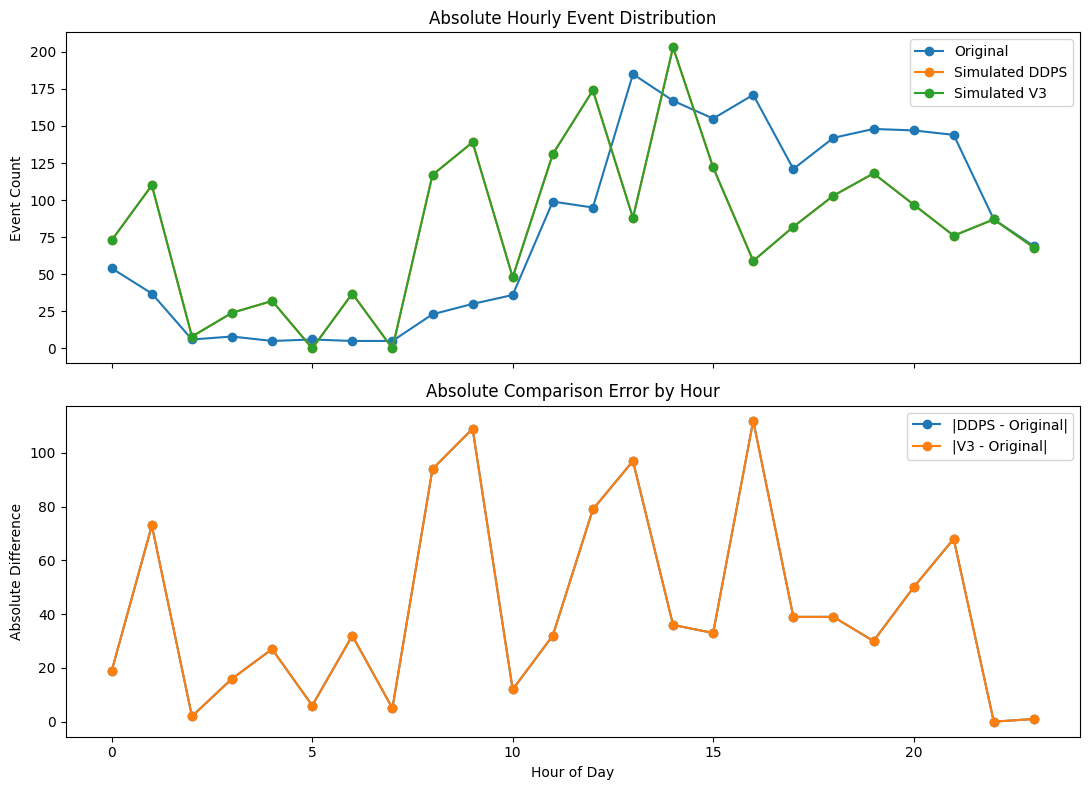

Mean absolute hourly error (DDPS): 42.12
Mean absolute hourly error (V3): 42.12


In [14]:
# Absolute comparison by hour (counts + absolute error vs Original)
hourly_original = log1["hour"].value_counts().sort_index().reindex(range(24), fill_value=0)
hourly_ddps = log2["hour"].value_counts().sort_index().reindex(range(24), fill_value=0)
hourly_v2 = log3["hour"].value_counts().sort_index().reindex(range(24), fill_value=0)

abs_err_ddps = (hourly_ddps - hourly_original).abs()
abs_err_v2 = (hourly_v2 - hourly_original).abs()

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Absolute hourly counts
axes[0].plot(hourly_original.index, hourly_original.values, marker="o", label="Original")
axes[0].plot(hourly_ddps.index, hourly_ddps.values, marker="o", label="Simulated DDPS")
axes[0].plot(hourly_v2.index, hourly_v2.values, marker="o", label=f"Simulated {tag}")
axes[0].set_ylabel("Event Count")
axes[0].set_title("Absolute Hourly Event Distribution")
axes[0].legend()

# Absolute error vs original
axes[1].plot(abs_err_ddps.index, abs_err_ddps.values, marker="o", label="|DDPS - Original|")
axes[1].plot(abs_err_v2.index, abs_err_v2.values, marker="o", label=f"|{tag} - Original|")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Absolute Difference")
axes[1].set_title("Absolute Comparison Error by Hour")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean absolute hourly error (DDPS): {abs_err_ddps.mean():.2f}")
print(f"Mean absolute hourly error ({tag}): {abs_err_v2.mean():.2f}")

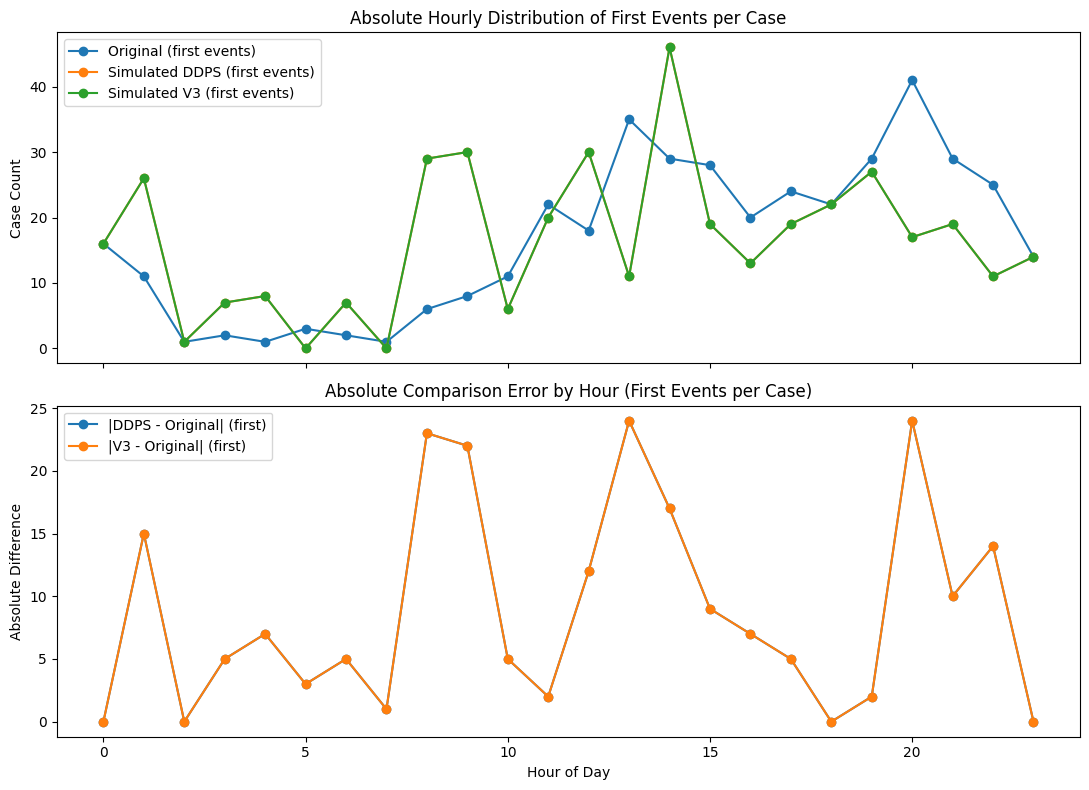

Mean absolute hourly error for first events (DDPS): 8.83
Mean absolute hourly error for first events (V3): 8.83


In [15]:
# Absolute comparison by hour for FIRST events per case (counts + absolute error vs Original)
def first_event_hourly_counts(log, ids):
    first_idx = log.groupby(ids.case)[ids.start_time].idxmin()
    first_events = log.loc[first_idx]
    return first_events[ids.start_time].dt.hour.value_counts().sort_index().reindex(range(24), fill_value=0)

first_hourly_original = first_event_hourly_counts(log1, original_ids)
first_hourly_ddps = first_event_hourly_counts(log2, simulated_ids)
first_hourly_v2 = first_event_hourly_counts(log3, simulated_ids)

first_abs_err_ddps = (first_hourly_ddps - first_hourly_original).abs()
first_abs_err_v2 = (first_hourly_v2 - first_hourly_original).abs()

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Absolute hourly counts (first events only)
axes[0].plot(first_hourly_original.index, first_hourly_original.values, marker="o", label="Original (first events)")
axes[0].plot(first_hourly_ddps.index, first_hourly_ddps.values, marker="o", label="Simulated DDPS (first events)")
axes[0].plot(first_hourly_v2.index, first_hourly_v2.values, marker="o", label=f"Simulated {tag} (first events)")
axes[0].set_ylabel("Case Count")
axes[0].set_title("Absolute Hourly Distribution of First Events per Case")
axes[0].legend()

# Absolute error vs original (first events only)
axes[1].plot(first_abs_err_ddps.index, first_abs_err_ddps.values, marker="o", label="|DDPS - Original| (first)")
axes[1].plot(first_abs_err_v2.index, first_abs_err_v2.values, marker="o", label=f"|{tag} - Original| (first)")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Absolute Difference")
axes[1].set_title("Absolute Comparison Error by Hour (First Events per Case)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Mean absolute hourly error for first events (DDPS): {first_abs_err_ddps.mean():.2f}")
print(f"Mean absolute hourly error for first events ({tag}): {first_abs_err_v2.mean():.2f}")

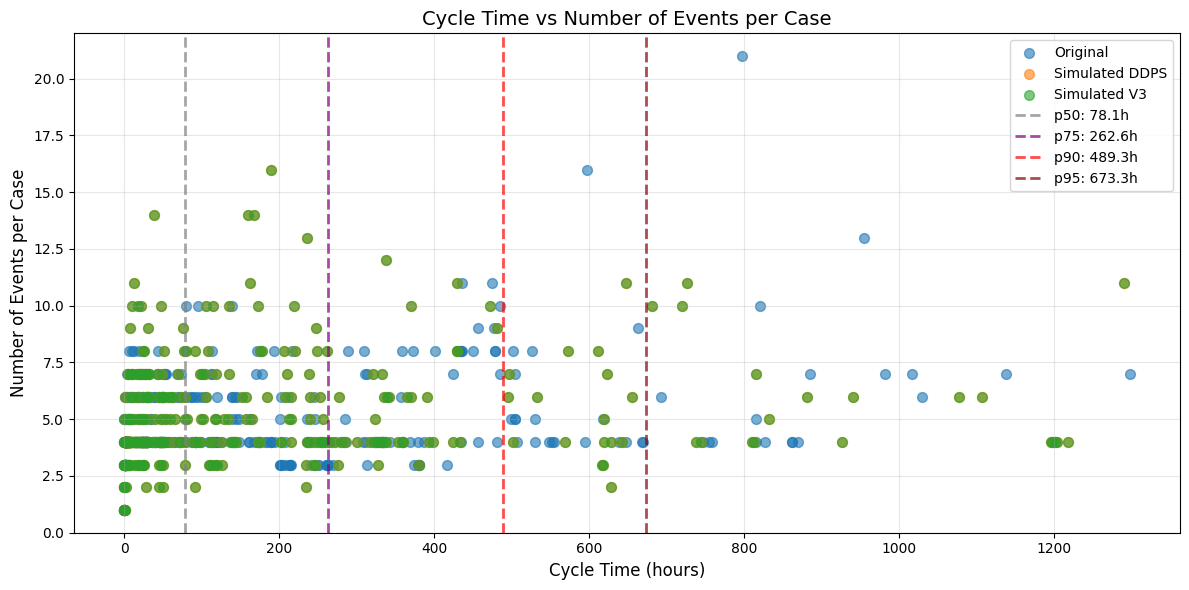

In [16]:
# Calculate number of events per case for each log
def events_per_case(log, ids):
    return log.groupby(ids.case).size()

events1 = events_per_case(log1, original_ids)
events2 = events_per_case(log2, simulated_ids)
events3 = events_per_case(log3, simulated_ids)

# Calculate percentiles for cycle times
percentiles = {
    'p50': ct1.quantile(0.50),
    'p75': ct1.quantile(0.75),
    'p90': ct1.quantile(0.90),
    'p95': ct1.quantile(0.95),
}

# Create scatter plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot scatter points for each log
ax.scatter(ct1, events1, alpha=0.6, s=50, label="Original", color='tab:blue')
ax.scatter(ct2, events2, alpha=0.6, s=50, label="Simulated DDPS", color='tab:orange')
ax.scatter(ct3, events3, alpha=0.6, s=50, label=f"Simulated {tag}", color='tab:green')

# Add vertical lines for percentiles
colors_percentile = {'p50': 'gray', 'p75': 'purple', 'p90': 'red', 'p95': 'darkred'}
for percentile_name, percentile_value in percentiles.items():
    ax.axvline(percentile_value, linestyle='--', linewidth=2, 
               label=f"{percentile_name}: {percentile_value:.1f}h", 
               color=colors_percentile[percentile_name], alpha=0.7)

ax.set_xlabel("Cycle Time (hours)", fontsize=12)
ax.set_ylabel("Number of Events per Case", fontsize=12)
ax.set_title("Cycle Time vs Number of Events per Case", fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

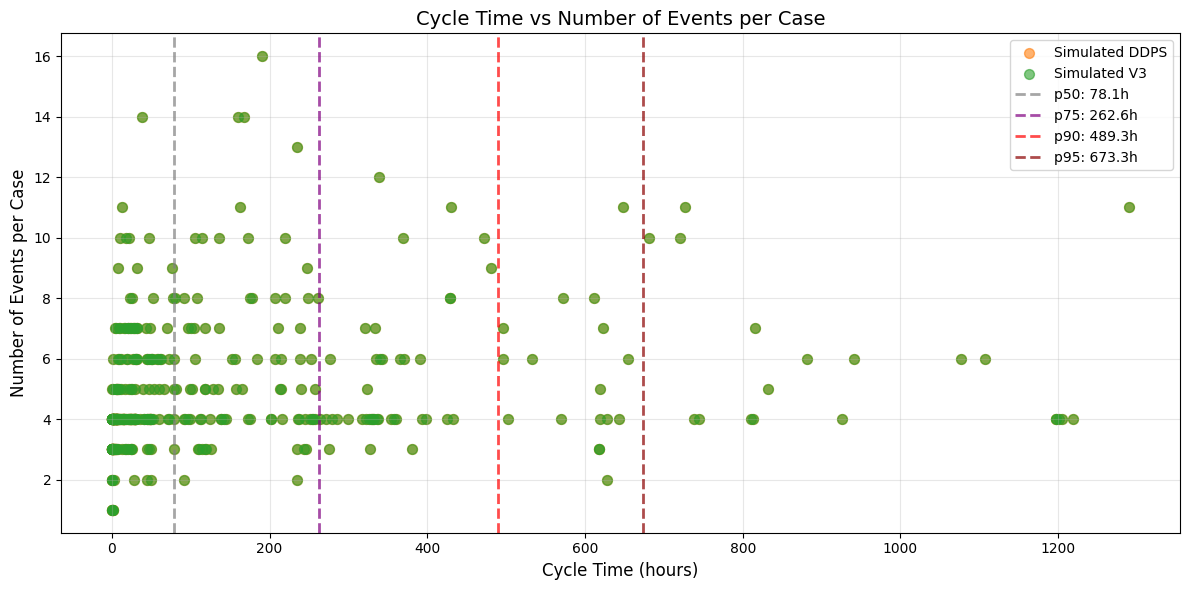

In [17]:
# Calculate number of events per case for each log
def events_per_case(log, ids):
    return log.groupby(ids.case).size()

events1 = events_per_case(log1, original_ids)
events2 = events_per_case(log2, simulated_ids)
events3 = events_per_case(log3, simulated_ids)

# Calculate percentiles for cycle times
percentiles = {
    'p50': ct1.quantile(0.50),
    'p75': ct1.quantile(0.75),
    'p90': ct1.quantile(0.90),
    'p95': ct1.quantile(0.95),
}

# Create scatter plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot scatter points for each log
ax.scatter(ct2, events2, alpha=0.6, s=50, label="Simulated DDPS", color='tab:orange')
ax.scatter(ct3, events3, alpha=0.6, s=50, label=f"Simulated {tag}", color='tab:green')

# Add vertical lines for percentiles
colors_percentile = {'p50': 'gray', 'p75': 'purple', 'p90': 'red', 'p95': 'darkred'}
for percentile_name, percentile_value in percentiles.items():
    ax.axvline(percentile_value, linestyle='--', linewidth=2, 
               label=f"{percentile_name}: {percentile_value:.1f}h", 
               color=colors_percentile[percentile_name], alpha=0.7)

ax.set_xlabel("Cycle Time (hours)", fontsize=12)
ax.set_ylabel("Number of Events per Case", fontsize=12)
ax.set_title("Cycle Time vs Number of Events per Case", fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()